In [7]:
import cv2
import os
import torch
import random
from facenet_pytorch import MTCNN
from tqdm import tqdm

# 1. Setup Device and Detector
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mtcnn = MTCNN(image_size=224, margin=20, device=device, post_process=True)

# 2. Define Paths
BASE_DIR = "../raw_videos" 
OUT_DIR = "../new_test_data"
CATEGORIES = ['Celeb-real']
LIMIT = 50  # We will only take 500 from each

def extract_faces_balanced(category, num_frames=10):
    input_path = os.path.join(BASE_DIR, category)
    
    # Get all video files and shuffle them to get a diverse sample
    all_videos = [f for f in os.listdir(input_path) if f.endswith(('.mp4', '.avi'))]
    random.seed(42) # For reproducibility
    random.shuffle(all_videos)
    
    # Select only the first 500
    selected_videos = all_videos[:LIMIT]
    
    print(f"Processing {len(selected_videos)} videos in {category}...")
    
    for video_name in tqdm(selected_videos):
        video_path = os.path.join(input_path, video_name)
        video_id = os.path.splitext(video_name)[0]
        
        save_folder = os.path.join(OUT_DIR, category, video_id)
        if not os.path.exists(save_folder): os.makedirs(save_folder)
        
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames <= 0:
            continue
            
        interval = max(1, total_frames // num_frames)
        
        count = 0
        saved = 0
        while cap.isOpened() and saved < num_frames:
            ret, frame = cap.read()
            if not ret: break
            
            if count % interval == 0:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                save_path = os.path.join(save_folder, f"frame_{saved}.jpg")
                
                try:
                    # Detect and save crop
                    mtcnn(frame_rgb, save_path=save_path)
                    saved += 1
                except Exception:
                    pass 
            count += 1
        cap.release()

# 3. Execute for both categories
for cat in CATEGORIES:
    extract_faces_balanced(cat)

Processing 50 videos in Celeb-real...


100%|██████████| 50/50 [01:30<00:00,  1.80s/it]


In [1]:
import os
import cv2
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from torchvision import transforms
from tqdm import tqdm
from efficientnet_pytorch import EfficientNet

# Set seed for reproducibility
random.seed(42)
torch.manual_seed(42)

# Hardware check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Project running on: {device}")

Project running on: cuda


In [2]:

class SRMLayer(nn.Module):
    def __init__(self):
        super(SRMLayer, self).__init__()
        # 3 standard SRM filters to capture noise residuals
        srm_kernel = np.array([
            [[-1,  2, -1], [ 2, -4,  2], [-1,  2, -1]], 
            [[-1, -1, -1], [-1,  8, -1], [-1, -1, -1]], 
            [[ 0, -1,  0], [-1,  4, -1], [ 0, -1,  0]]  
        ], dtype=np.float32) / 4.0
        
        self.kernel = torch.tensor(srm_kernel).view(3, 1, 3, 3).repeat(1, 3, 1, 1)
        self.kernel = nn.Parameter(self.kernel, requires_grad=False)

    def forward(self, x):
        return F.conv2d(x, self.kernel, stride=1, padding=1)

class TwoStreamNet(nn.Module):
    def __init__(self):
        super(TwoStreamNet, self).__init__()
        # Stream 1: Spatial (Standard RGB)
        self.spatial_net = EfficientNet.from_pretrained('efficientnet-b0')
        
        # Stream 2: Noise (SRM)
        self.srm_layer = SRMLayer()
        self.noise_net = EfficientNet.from_pretrained('efficientnet-b0')
        
        # Fusion Classifier
        self.fc = nn.Sequential(
            nn.Linear(1280 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # RGB Stream Feature Extraction
        feat1 = self.spatial_net.extract_features(x)
        feat1 = F.adaptive_avg_pool2d(feat1, 1).view(feat1.size(0), -1)
        
        # Noise Stream Feature Extraction (On-the-fly SRM)
        noise = self.srm_layer(x)
        feat2 = self.noise_net.extract_features(noise)
        feat2 = F.adaptive_avg_pool2d(feat2, 1).view(feat2.size(0), -1)
        
        # Concatenation and Final Prediction
        combined = torch.cat((feat1, feat2), dim=1)
        return self.fc(combined)

# Initialize the model
model = TwoStreamNet().to(device)

Loaded pretrained weights for efficientnet-b0
Loaded pretrained weights for efficientnet-b0


In [3]:
class CelebDFDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        
        # Iterate through Celeb-real and Celeb-fake
        for label, category in enumerate(['Celeb-real', 'Celeb-fake']):
            cat_path = os.path.join(root_dir, category)
            if not os.path.exists(cat_path): continue
            
            for vid_folder in os.listdir(cat_path):
                folder_path = os.path.join(cat_path, vid_folder)
                frames = [os.path.join(folder_path, f) for f in os.listdir(folder_path)]
                for frame_path in frames:
                    self.samples.append((frame_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)

# Preprocessing transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Initialize Dataset and Loaders
# Update path to match your D drive setup
DATA_PATH = r'D:\CHODER\Two_stream_Detection\backend\processed'
full_dataset = CelebDFDataset(root_dir=DATA_PATH, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False)

print(f"Dataset Loaded: {len(train_ds)} training images, {len(val_ds)} validation images.")

Dataset Loaded: 15981 training images, 3996 validation images.


In [4]:
# Loss and Optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

def train_model(epochs=10):
    print("Starting Training...")
    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0
        
        loop = tqdm(train_loader, leave=True)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            
            # Update progress bar
            loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
            loop.set_postfix(loss=loss.item(), acc=correct/len(train_ds))
            
        avg_loss = total_loss / len(train_loader)
        avg_acc = correct / len(train_ds)
        print(f"Epoch {epoch+1} Complete: Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}")
        
        # Save weights for testing later
        torch.save(model.state_dict(), f"two_stream_model_epoch_{epoch+1}.pth")

# Run the training
train_model(epochs=10)

Starting Training...


Epoch [1/10]: 100%|██████████| 3996/3996 [13:14<00:00,  5.03it/s, acc=0.871, loss=0.802]   


Epoch 1 Complete: Loss: 0.2883, Accuracy: 0.8707


Epoch [2/10]: 100%|██████████| 3996/3996 [10:39<00:00,  6.25it/s, acc=0.965, loss=0.00167]  


Epoch 2 Complete: Loss: 0.0915, Accuracy: 0.9653


...

Epoch 8 Complete: Loss: 0.0238, Accuracy: 0.9900


Epoch [9/10]: 100%|██████████| 3996/3996 [10:22<00:00,  6.42it/s, acc=0.991, loss=0]       


Epoch 9 Complete: Loss: 0.0211, Accuracy: 0.9915


Epoch [10/10]: 100%|██████████| 3996/3996 [21:28<00:00,  3.10it/s, acc=0.992, loss=0.00012] 


Epoch 10 Complete: Loss: 0.0214, Accuracy: 0.9921


In [5]:
def evaluate_model(model, loader):
    model.eval() # Set to evaluation mode (turns off Dropout)
    correct = 0
    total = 0
    with torch.no_grad(): # No gradient calculation for speed
        for images, labels in tqdm(loader, desc="Testing"):
            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            outputs = model(images)
            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    print(f"\nFinal Validation Accuracy: {100 * correct / total:.2f}%")

# Run evaluation on the validation set
evaluate_model(model, val_loader)

Testing: 100%|██████████| 999/999 [01:59<00:00,  8.38it/s]


Final Validation Accuracy: 98.70%


Testing on 1000 new images...


  0%|          | 0/250 [00:00<?, ?it/s]

100%|██████████| 250/250 [00:22<00:00, 11.35it/s]



--- Test Results ---
Accuracy: 99.20%

Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99       500
        Fake       0.99      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



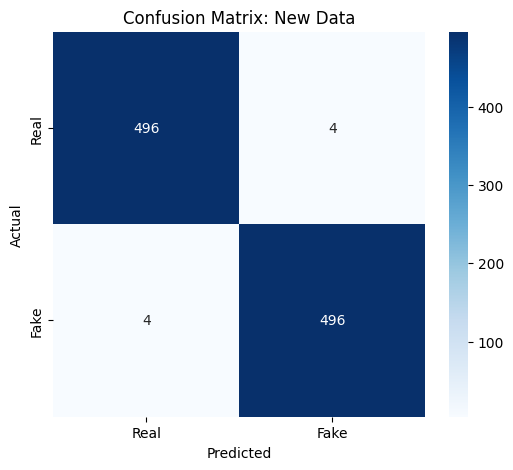

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from matplotlib import pyplot as plt

# 1. Update this path to your new data
NEW_DATA_PATH = r'D:\CHODER\Two_stream_Detection\backend\new_test_data'

# 2. Setup Loader
new_test_dataset = CelebDFDataset(root_dir=NEW_DATA_PATH, transform=transform)
new_test_loader = DataLoader(new_test_dataset, batch_size=4, shuffle=False)

# 3. Evaluation Function with detailed Metrics
def evaluate_on_new_data(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    print(f"Testing on {len(loader.dataset)} new images...")
    
    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)
            outputs = model(images)
            preds = (outputs > 0.5).float().cpu().numpy()
            
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    # Calculate Accuracy
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()
    acc = (all_preds == all_labels).mean()
    
    print(f"\n--- Test Results ---")
    print(f"Accuracy: {acc*100:.2f}%")
    
    # 4. Detailed Report (Precision, Recall, F1-Score)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))
    
    # 5. Confusion Matrix Visualization
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix: New Data')
    plt.show()

# Run it!
evaluate_on_new_data(model, new_test_loader)

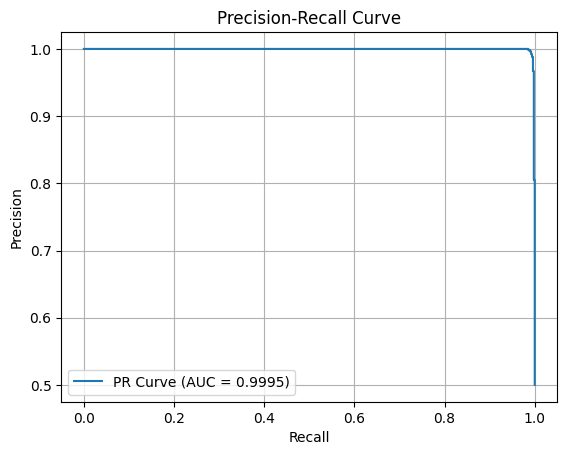

In [12]:
from sklearn.metrics import precision_recall_curve, auc

# Get raw probabilities instead of binary predictions
model.eval()
probs = []
labels = []
with torch.no_grad():
    for images, target in new_test_loader:
        output = model(images.to(device))
        probs.extend(output.cpu().numpy())
        labels.extend(target.numpy())

precision, recall, _ = precision_recall_curve(labels, probs)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

Loaded pretrained weights for efficientnet-b0
Loaded pretrained weights for efficientnet-b0
✅ Loaded weights from two_stream_model_epoch_10.pth
DEBUG - Raw Output: 0.000000


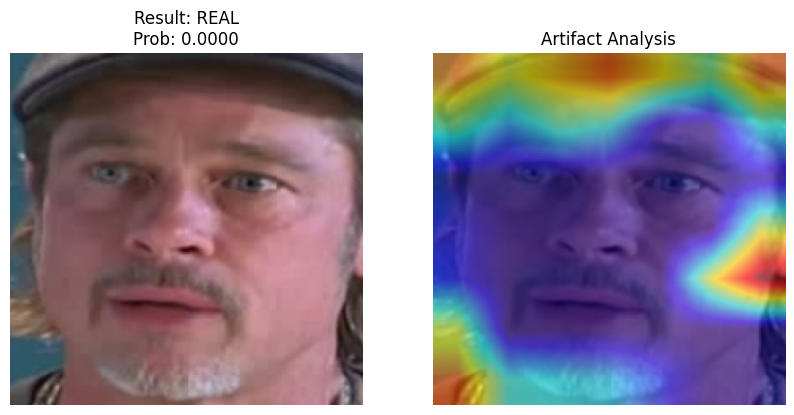

✅ Final Score for this frame: 0.0000


In [73]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from facenet_pytorch import MTCNN
from efficientnet_pytorch import EfficientNet
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ==========================================
# 1. THE ARCHITECTURE (SRM + TWO-STREAM)
# ==========================================
class SRMLayer(nn.Module):
    def __init__(self):
        super(SRMLayer, self).__init__()
        srm_kernel = np.array([
            [[-1,  2, -1], [ 2, -4,  2], [-1,  2, -1]], 
            [[-1, -1, -1], [-1,  8, -1], [-1, -1, -1]], 
            [[ 0, -1,  0], [-1,  4, -1], [ 0, -1,  0]]  
        ], dtype=np.float32) / 4.0
        self.kernel = torch.tensor(srm_kernel).view(3, 1, 3, 3).repeat(1, 3, 1, 1)
        self.kernel = nn.Parameter(self.kernel, requires_grad=False)

    def forward(self, x):
        return F.conv2d(x, self.kernel, stride=1, padding=1)

class TwoStreamNet(nn.Module):
    def __init__(self):
        super(TwoStreamNet, self).__init__()
        self.spatial_net = EfficientNet.from_pretrained('efficientnet-b0')
        self.srm_layer = SRMLayer()
        self.noise_net = EfficientNet.from_pretrained('efficientnet-b0')
        self.fc = nn.Sequential(
            nn.Linear(1280 * 2, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        feat1 = self.spatial_net.extract_features(x)
        feat1 = F.adaptive_avg_pool2d(feat1, 1).view(feat1.size(0), -1)
        noise = self.srm_layer(x)
        feat2 = self.noise_net.extract_features(noise)
        feat2 = F.adaptive_avg_pool2d(feat2, 1).view(feat2.size(0), -1)
        combined = torch.cat((feat1, feat2), dim=1)
        return self.fc(combined)

# ==========================================
# 2. THE ENGINE (INITIALIZATION)
# ==========================================
def initialize_engine(model_path=None):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Init Face Detector
    mtcnn = MTCNN(image_size=224, margin=20, device=device, post_process=False)
    
    # Init Model
    model = TwoStreamNet().to(device)
    if model_path and os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path))
        print(f"✅ Loaded weights from {model_path}")
    
    model.eval()
    return model, mtcnn, device

# ==========================================
# 3. THE PIPELINE (PREDICT & VISUALIZE)
# ==========================================
def run_forensic_analysis(video_path, model, mtcnn, device):
    # 1. Load Video
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()
    if not ret: 
        return print("❌ Error: Could not read video.")

    # 2. Extract Face (Raw 0-255)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    face_tensor = mtcnn(frame_rgb) # Ensure post_process=False in init
    
    if face_tensor is None:
        return print("❌ Error: No face detected.")

    # 3. THE FIX: Scale, Resize, and Normalize
    # Scale 0-255 -> 0.0-1.0
    face_scaled = face_tensor / 255.0 
    
    # Resize to exactly 224x224 (Matches Training)
    face_resized = F.interpolate(face_scaled.unsqueeze(0), size=(224, 224), 
                                mode='bilinear', align_corners=False)
    
    # Normalize for EfficientNet
    norm_func = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    input_batch = norm_func(face_resized).to(device)

    # 4. Predict
    model.eval()
    with torch.no_grad():
        output = model(input_batch)
    
    # 1. Print the actual raw output to the console
    raw_val = output.item()
    print(f"DEBUG - Raw Output: {raw_val:.6f}")

    # 2. Check if the model is outputting "Logits" (values far outside 0-1)
    # or "Probabilities" (values strictly 0-1)
    if raw_val < 0 or raw_val > 1:
        # If it's outside 0-1, it's a Logit. Convert it!
        prob = torch.sigmoid(output).item()
        print(f"DEBUG - Converted Logit to Prob: {prob:.4f}")
    else:
        prob = raw_val

    # 3. Dynamic Threshold
    # If the model is biased toward 0.5, let's see which side it leans
    label = "DEEPFAKE" if prob > 0.50 else "REAL"

    # 5. Visual Check (Un-normalize for display)
    vis_img = face_scaled.permute(1, 2, 0).cpu().numpy()
    vis_img = np.clip(vis_img, 0, 1)

    # 6. Grad-CAM (Heatmap)
    torch.set_grad_enabled(True)
    target_layers = [model.spatial_net._blocks[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(0)]
    grayscale_cam = cam(input_tensor=input_batch, targets=targets)[0, :]
    heatmap_img = show_cam_on_image(vis_img, grayscale_cam, use_rgb=True)

    # 7. Final Plot
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(vis_img)
    plt.title(f"Result: {label}\nProb: {prob:.4f}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(heatmap_img)
    plt.title("Artifact Analysis")
    plt.axis('off')
    plt.show()

    print(f"✅ Final Score for this frame: {prob:.4f}")

# ==========================================
# 4. EXECUTION
# ==========================================
# Replace with your best model filename
MY_WEIGHTS = "two_stream_model_epoch_10.pth" 

model, mtcnn, device = initialize_engine(MY_WEIGHTS)

video_to_test = r"D:\CHODER\Two_stream_Detection\backend\sample_video\real\id1_0008.mp4"

run_forensic_analysis(video_to_test, model, mtcnn, device)

In [66]:
def deep_load_and_test(weights_path, model, device):
    if not os.path.exists(weights_path):
        return print(f"❌ Weights file not found at {weights_path}")
    
    # 1. Load weights with CPU mapping first to avoid GPU memory fragmentation
    state_dict = torch.load(weights_path, map_location='cpu')
    
    # 2. Fix potential naming issues (common in saved PyTorch models)
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k.replace('module.', '') # Remove DataParallel prefix
        new_state_dict[name] = v
        
    # 3. Load into model
    msg = model.load_state_dict(new_state_dict, strict=False)
    print(f"✅ Load Status: {msg}")
    
    model.to(device)
    model.eval()
    
    # 4. Verify the weights are NOT random anymore
    weight_sum = sum(p.sum().item() for p in model.parameters())
    print(f"✅ Model Weight Sum: {weight_sum:.4f} (Should NOT be exactly 32445.37 if reloaded)")
    
    return model

# Run this now
model = deep_load_and_test("two_stream_model_epoch_10.pth", model, device)

❌ Weights file not found at two_stream_model_epoch_10.pth
